# Models

In [36]:
import numpy as np
from scipy.stats import gamma, norm
# get truncated gamma and normal distributions
from scipy.stats import truncnorm
np.random.seed(42)


class SlopeMAPPerceptual:
    def __init__(self, *args, **kwargs):
        # Leak parameter
        self.leak = kwargs.get('leak', 0)
        # x values = forcefield values
        self.x = kwargs.get('x', np.linspace(-1, 1, 9).round(2))
        if not isinstance(self.x, np.ndarray):
            self.x = np.array(list(self.x))
        
        # Initialize outcome-based prior
        # Slope prior mean and standard deviation
        self.slope_prior_mean = kwargs.get('slope_prior_mean', 0.0)  # Default mean to 0
        self.slope_prior_std = kwargs.get('slope_prior_std', 1.0)    # Default std to 1.0
        
        # Ensure the prior standard deviation is positive
        self.slope_prior_std = max(0.001, self.slope_prior_std)  # Set a minimum value
        
        # Possible values for the slope
        self.slope_range = kwargs.get('slope_range', np.arange(-10, 10, 0.1))
        
        # Initialize log-posterior for the slope with prior
        self.lp_slope = np.log(norm.pdf(self.slope_range, self.slope_prior_mean, self.slope_prior_std))
        
        # Define logit function
        self.logit = lambda x: 1 / (1 + np.exp(x))

        self.binary = kwargs.get('binary', True)
        
    def perceptual_update(self, choice, outcome, spaceship_estimate=None):
        """Update the log-posterior of the slope based on observed data."""
        if self.binary:
            v = self.slope_range * choice
            v = v - v * 2 * outcome  # Switch to negative if forcefield destroyed
    
            # Binary outcome likelihood
            ll = np.log(self.logit(v))
        else:
           # Continuous outcome: outcome = sigmoid(slope * x) * spaceship reward
            logits = self.slope_range * choice

            # logistic probabilities
            p = self.logit(logits)

            # in the generative process of exp. 3, spaceship rewards is
            # multiplied by shield value to produce an outcome
            # Use observed outcome and estimated spaceship to derive implied sigmoid output
            pred_outcomes = np.clip(outcome / spaceship_estimate, 1e-6, 1 - 1e-6)
            # pred_outcomes = p * (spaceship_estimate * 2)

            # gaussian likelihood: compare each pred_outcome to the obtained outcome
            likelihoods = np.exp(-0.5 * ((p-pred_outcomes) ** 2) / 0.1)
            # likelihoods = np.exp(-0.5 * ((outcome - pred_outcomes) ** 2) / 0.2)

            # posterior
            posterior = likelihoods / np.sum(likelihoods)

            ll = np.log(posterior)

        # Update log posterior
        self.lp_slope += ll
           
    def predict_shield_p(self, shields):
        """Predict outcomes (linear or logit) for given forcefields."""
        # Predict for 2 displayed forcefields
        x = np.arange(len(self.x))
        to_select = x[np.isin(self.x, shields)]
        slope = -self.get_slope() * int(self.binary) + self.get_slope() * int(not self.binary)
        return self.logit(slope * self.x[to_select])
    
    def get_slope(self):
        """Compute the current slope as the weighted mean of the slope range."""
        w = np.exp(self.lp_slope - np.max(self.lp_slope))
        slope = np.sum(w * self.slope_range) / np.sum(w)
        return slope

class NormativePerceptual:
    def __init__(self, prior_mean=[0, 0], prior_cov=[[1, 0], [0, 1]], burn_in=500, samples=1000):
        """
        Bayesian Probit Model using Gibbs sampling.
        
        Parameters:
            prior_mean : list of prior means [β, α]
            prior_cov : prior covariance matrix (2x2)
            burn_in : number of burn-in samples
            samples : number of posterior samples after burn-in
        """
        self.m0 = np.array(prior_mean)
        self.S0 = np.array(prior_cov)
        self.burn_in = burn_in
        self.samples = samples
        self.theta_samples = []  # to store (β, α) samples
        
    def perceptual_update(self, z, b):
        """
        Perform Gibbs sampling given data.

        Parameters:
            z : 1D numpy array of shield strengths
            b : 1D numpy array of binary outcomes (0 or 1)
        """
        n = len(z)
        Z = np.column_stack((np.ones(n), z))  # Design matrix
        theta = np.random.multivariate_normal(self.m0, self.S0)  # Initial guess for (β, α)

        all_samples = []

        for t in range(self.burn_in + self.samples):
            # Step 1: sample latent u
            eta = Z @ theta
            u = np.zeros(n)

            for i in range(n):
                if b[i] == 1:
                    a, b_ = (0 - eta[i]), np.inf
                else:
                    a, b_ = -np.inf, (0 - eta[i])
                u[i] = truncnorm.rvs(a, b_, loc=eta[i], scale=1)

            # Step 2: sample (β, α)
            S_post_inv = np.linalg.inv(self.S0) + Z.T @ Z
            S_post = np.linalg.inv(S_post_inv)
            m_post = S_post @ (np.linalg.inv(self.S0) @ self.m0 + Z.T @ u)
            theta = np.random.multivariate_normal(m_post, S_post)

            if t >= self.burn_in:
                all_samples.append(theta)

        self.theta_samples = np.array(all_samples)
        
    def perceptual_update2(self, z, b):
        """
        Perform Gibbs sampling given data.

        Parameters:
            z : 1D numpy array of shield strengths
            b : 1D numpy array of binary outcomes (0 or 1)
        """
        n = len(z)
        Z = np.column_stack((np.ones(n), z))  # Design matrix
        theta = np.random.multivariate_normal(self.m0, self.S0)  # Initial guess for (β, α)

        all_samples = []
                # Pre-calculate constant terms
        S0_inv = np.linalg.inv(self.S0)
        ZtZ = Z.T @ Z
        S0_inv_m0 = S0_inv @ self.m0

        for t in range(self.burn_in + self.samples):
            # Step 1: sample latent u
            eta = Z @ theta
            # Vectorized sampling of u
            idx_b1 = (b == 1)
            idx_b0 = (b == 0)

            a_bounds = np.full(n, -np.inf)
            b_bounds = np.full(n, np.inf)

            a_bounds[idx_b1] = -eta[idx_b1]
            b_bounds[idx_b0] = -eta[idx_b0]

            u = truncnorm.rvs(a_bounds, b_bounds, loc=eta, scale=1)

            # Step 2: sample (β, α)
            # Step 2: sample (β, α)
            S_post_inv = S0_inv + ZtZ  # Use pre-calculated terms            
            S_post = np.linalg.inv(S_post_inv)
          
            m_post = S_post @ (S0_inv_m0 + Z.T @ u) # Use pre-calculated S0_inv @ m0
            theta = np.random.multivariate_normal(m_post, S_post)


            if t >= self.burn_in:
                all_samples.append(theta)

        self.theta_samples = np.array(all_samples)

    def perceptual_update3(self, z, b):
        """
        Perform Gibbs sampling given data with a fallback for small sample sizes
        or invalid truncation bounds.

        Parameters:
            z : 1D numpy array of shield strengths
            b : 1D numpy array of binary outcomes (0 or 1)
        """
        if self.model == 'value':
            return 
        
        n = len(z)
        Z = np.column_stack((np.ones(n), z))  # Design matrix
        theta = np.random.multivariate_normal(self.m0.ravel(), self.S0)  # Initial guess for (β, α)

        all_samples = []

        # Pre-calculate constant terms
        S0_inv = np.linalg.inv(self.S0)
        ZtZ = Z.T @ Z
        S0_inv_m0 = S0_inv @ self.m0

        for t in range(self.burn_in + self.samples):
            # Step 1: sample latent u
            eta = Z @ theta
            a_bounds = np.full(n, -np.inf)
            b_bounds = np.full(n, np.inf)

            # Adjust bounds based on b
            a_bounds[b == 1] = -eta[b == 1]
            b_bounds[b == 0] = -eta[b == 0]

            # Safe sampling with fallback for small n or invalid bounds
            fallback = n < 10 or np.any(a_bounds > b_bounds)
            if fallback:
                u = np.zeros(n)
                for i in range(n):
                    a, b_ = a_bounds[i], b_bounds[i]
                    if a > b_:
                        raise ValueError(f"Invalid truncation bounds at index {i}: a > b")
                    u[i] = truncnorm.rvs(a, b_, loc=eta[i], scale=1)
            else:
                u = truncnorm.rvs(a_bounds, b_bounds, loc=eta, scale=1)

            # Step 2: sample (β, α)
            S_post_inv = S0_inv + ZtZ
            S_post = np.linalg.inv(S_post_inv)
            m_post = S_post @ (S0_inv_m0 + Z.T @ u)
            theta = np.random.multivariate_normal(m_post, S_post)

            if t >= self.burn_in:
                all_samples.append(theta)

        self.theta_samples = np.array(all_samples)


    def predict_shield_p(self, shield):
        """
        Compute predictive probability p(b=1 | z) using posterior samples.

        Parameters:
            shield : scalar value (z*)

        Returns:
            Posterior predictive probability for that shield strength.
        """
        if self.model == 'value':
            return 1.0
        if len(self.theta_samples) == 0:
            raise ValueError("You must run perceptual_update() first.")
        

        β = self.theta_samples[:, 0]
        α = self.theta_samples[:, 1]
        preds = norm.cdf(β + α * shield)
        return preds.mean()

class NormativeValue:
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1):
        """
        Bayesian reward model using Normal-Gamma conjugate prior for multiple spaceships.

        Parameters:
            spaceship_ids : list of spaceship identifiers (ints or strings)
            mu0, kappa0, alpha0, beta0 : prior hyperparameters for all spaceships
        """
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

        self.data = {sid: [] for sid in spaceship_ids}

    def value_update(self, spaceship_id, reward):
        """
        Add an observed reward for a specific spaceship.

        Parameters:
            spaceship_id : ID of the spaceship
            reward : observed scalar reward
        """
        if spaceship_id not in self.data:
            raise ValueError(f"Unknown spaceship ID: {spaceship_id}")
        self.data[spaceship_id].append(reward)

    def compute_posterior(self, spaceship_id):
        """
        Compute the posterior parameters for a given spaceship.
        """
        if self.model == 'perceptual':
            return 
            
        xi = np.array(self.data[spaceship_id])
        n = len(xi)

        if n == 0:
            return self.mu0, self.kappa0, self.alpha0, self.beta0

        x_bar = xi.mean()
        S = np.sum((xi - x_bar) ** 2)

        kappa_n = self.kappa0 + n
        mu_n = (self.kappa0 * self.mu0 + n * x_bar) / kappa_n
        alpha_n = self.alpha0 + n / 2
        beta_n = self.beta0 + 0.5 * S + (self.kappa0 * n * (x_bar - self.mu0) ** 2) / (2 * kappa_n)

        return mu_n, kappa_n, alpha_n, beta_n

    def posterior_predictive_mean(self, spaceship_id):
        """
        Return the expected value (mean) of the predictive distribution for a spaceship.
        """
        if self.model == 'perceptual':
            return 1.0
        mu_n, _, _, _ = self.compute_posterior(spaceship_id)
        return mu_n

    def sample_posterior(self, spaceship_id, n_samples=1000):
        """
        Sample possible mean rewards for a spaceship from the posterior predictive distribution.
        """
        mu_n, kappa_n, alpha_n, beta_n = self.compute_posterior(spaceship_id)

        tau_samples = gamma.rvs(a=alpha_n, scale=1 / beta_n, size=n_samples)
        mu_samples = norm.rvs(loc=mu_n, scale=1 / np.sqrt(kappa_n * tau_samples))
        #truncated normal distribution
        mu_samples = truncnorm.rvs(a=0, b=1, loc=mu_samples, scale=1 / np.sqrt(kappa_n * tau_samples))

        return mu_samples

    def reset(self, spaceship_id=None):
        """
        Reset observations for one or all spaceships.
        """
        if spaceship_id is None:
            for sid in self.data:
                self.data[sid] = []
        else:
            self.data[spaceship_id] = []

class NormativePolicy(NormativeValue):
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1,
                 burn_in=500, samples=1000, model=False, omega=0, beta=1, binary=True):
        NormativeValue.__init__(self, spaceship_ids, mu0, kappa0, alpha0, beta0)
        if model == 'gibbs':
            print('model is gibbs')
            self.perceptual = NormativePerceptual(burn_in=burn_in, samples=samples)
            self.perceptual.model = 'gibbs'
        else:
            # print('model is map')
            self.perceptual = SlopeMAPPerceptual(binary=binary)
            self.perceptual.model = 'map'
        self.perceptual_update = self.perceptual.perceptual_update
        self.predict_shield_p = self.perceptual.predict_shield_p
        
        self.omega = omega
        self.beta = beta
        self.model = model
        self.v_log_ratio_list = []
        self.p_log_ratio_list = []
        self.v_log_ratio = 0
        self.p_log_ratio = 0

    def expected_reward(self, spaceship_id, shield_strength):
        """
        Compute the expected reward for a spaceship given a shield strength z

        Parameters:
            spaceship_id : spaceship ID
            shield_strength : scalar z*

        Returns:
            Expected reward E[Y | z*, Z, B, X]
        """
        # Step 1: compute P(b=1 | z*) from probit model
        p_success = 1.0  # Default if no shield strength is provided
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)

        # Step 2: compute E[μ | X] from reward model
        E_mu = 1.0 
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n

        # Step 3: combine both
        return p_success, E_mu

    def get_spaceship_mean(self, spaceship_id):
        E_mu = 1.0
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n
        return E_mu
    
    def get_shield_probability(self, shield_strength):
        p_success = 1.0
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)
        return p_success

    def choose(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        self.v_log_ratio_list.append(v_lr)  
        self.p_log_ratio_list.append(p_lr)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
    
    def get_likelihood(self, spaceships, shields):
        """
        computes the likelihood of both options
        given the shield strengths and  spaceships
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        # estimated p of choosing option 1
        ep1 = 1/(1 + np.exp(self.beta*-dv))

        return [ep1, 1-ep1]
        
        
    def choose2(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        self.v_log_ratio = np.log(v1) - np.log(v2)
        self.p_log_ratio = np.log(p1) - np.log(p2)

        # # v_lr = v_lr / np.std(self.v_log_ratio_list)
        # # p_lr = p_lr / np.std(self.p_log_ratio_list)

        # dv = (1-self.omega) * v_lr + self.omega * p_lr

        # return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
        
        # # not a dic now but two arrays
        expected_rewards = [
            sid*shield
            for sid, shield in zip([v1, v2], [p1, p2])
        ]
        return np.argmax(expected_rewards)

        #best_id = max(expected_rewards, key=expected_rewards.get)
        


In [37]:
import sys
sys.path.append('..')

from src.visualization import plot_settings
import pandas as pd
import numpy as np
import seaborn as sns
import ast

df = pd.read_csv('../data/processed/df.csv')
df['s'] = df.s.apply(ast.literal_eval)
print('N =', len(df.prolificID.unique()))

N = 245


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
from joblib import Parallel, delayed

agents = df[df.expName.isin(['exp2'])].copy()
omegas = np.round(np.arange(0, 1.05, 0.05), 2)
betas = np.arange(0, 101, 5)
slope = 2
ff_values = np.round(np.linspace(-1, 1, 9), 2)
logistic = lambda x: 1/(1+np.exp(-slope*x))
pp = {i: np.round(logistic(i), 2) for i in ff_values}
n_sim = 1

valid_prolific_ids = set(df.prolificID.unique())

# Pre-extract per-agent numpy arrays to avoid sending the full DataFrame to workers
agent_data_cache = {}
for agent in agents.agent.unique():
    if agent not in valid_prolific_ids:
        continue
    df_agent = df[(df.agent == agent) & (df.session.isin([0, 1, 2, 3]))].sort_values(by=['session', 't'])
    df_agent = df_agent.loc[df_agent.choice.isin([1, 2])]
    agent_data_cache[agent] = dict(
        s_vals        = df_agent.s.values,
        ff1_vals      = df_agent.ff1.values,
        ff2_vals      = df_agent.ff2.values,
        session_vals  = df_agent.session.values,
        ev1_vals      = df_agent.ev1.values,
        ev2_vals      = df_agent.ev2.values,
        outcome1_vals = df_agent.outcome1.values,
        outcome2_vals = df_agent.outcome2.values,
        exp_val       = df_agent.expName.values[0],
        ntrials       = df_agent.shape[0],
    )

def simulate_one(omega, beta, agent, data, n_sim):
    """Run n_sim simulations for one (omega, agent) pair and return a list of result dicts."""
    s_vals        = data['s_vals']
    ff1_vals      = data['ff1_vals']
    ff2_vals      = data['ff2_vals']
    session_vals  = data['session_vals']
    ev1_vals      = data['ev1_vals']
    ev2_vals      = data['ev2_vals']
    outcome1_vals = data['outcome1_vals']
    outcome2_vals = data['outcome2_vals']
    exp_val       = data['exp_val']
    ntrials       = data['ntrials']

    local_results = []
    for sim in range(n_sim):
        m = NormativePolicy(
            spaceship_ids=[280, 380, 500, 620, 720],
            omega=omega,
            beta=beta,
            binary=exp_val != 'exp3',
        )
        opti_ev_count = 0
        for t in range(ntrials):
            c = m.choose(spaceships=s_vals[t], shields=[ff1_vals[t], ff2_vals[t]])
            if (c == 0 and ev1_vals[t] >= ev2_vals[t]) or (c == 1 and ev2_vals[t] >= ev1_vals[t]):
                opti_ev_count += 1
            r_sim = (outcome1_vals[t] * (c == 0) + outcome2_vals[t] * (c == 1)) / 1000
            ff_chosen = [ff1_vals[t], ff2_vals[t]][c]
            destroy_sim = int(np.random.random() < 1 / (1 + np.exp(-2 * ff_chosen)))
            spaceship_estimate = m.get_spaceship_mean(s_vals[t][c])
            if session_vals[t] in (1, 3):
                if exp_val == 'exp3':
                    m.perceptual_update(ff_chosen, r_sim, spaceship_estimate)
                else:
                    m.perceptual_update(ff_chosen, destroy_sim)
            if session_vals[t] in (0, 2, 3):
                if destroy_sim or exp_val == 'exp3':
                    m.value_update(s_vals[t][c], r_sim)
        local_results.append({'omega': omega, 'beta': beta, 'agent': agent, 'avg_opti_ev': opti_ev_count / ntrials})
    return local_results

# Build flat task list (skip agents not in prolificID)
tasks = [
    (omega, beta, agent, agent_data_cache[agent])
    for omega in omegas
    for beta in betas
    for agent in agents.agent.unique()
    if agent in agent_data_cache
]

# Parallel execution — n_jobs=-1 uses all available CPU cores
all_results_nested = Parallel(n_jobs=-2, backend='loky', verbose=0)(
    delayed(simulate_one)(omega, beta, agent, data, n_sim)
    for omega, beta, agent, data in tqdm.tqdm(tasks, desc='Simulating')
)

results_omega = [item for subresult in all_results_nested for item in subresult]
df_omega_sim = pd.DataFrame(results_omega)

# Heatmap: omega (x) vs agent (y), values = avg opti_ev
pivot = df_omega_sim.groupby(['agent', 'omega'])['avg_opti_ev'].mean().unstack('omega')

# Mean across agents
mean_per_omega = df_omega_sim.groupby('omega')['avg_opti_ev'].mean()



Simulating:   0%|          | 0/28224 [00:00<?, ?it/s]

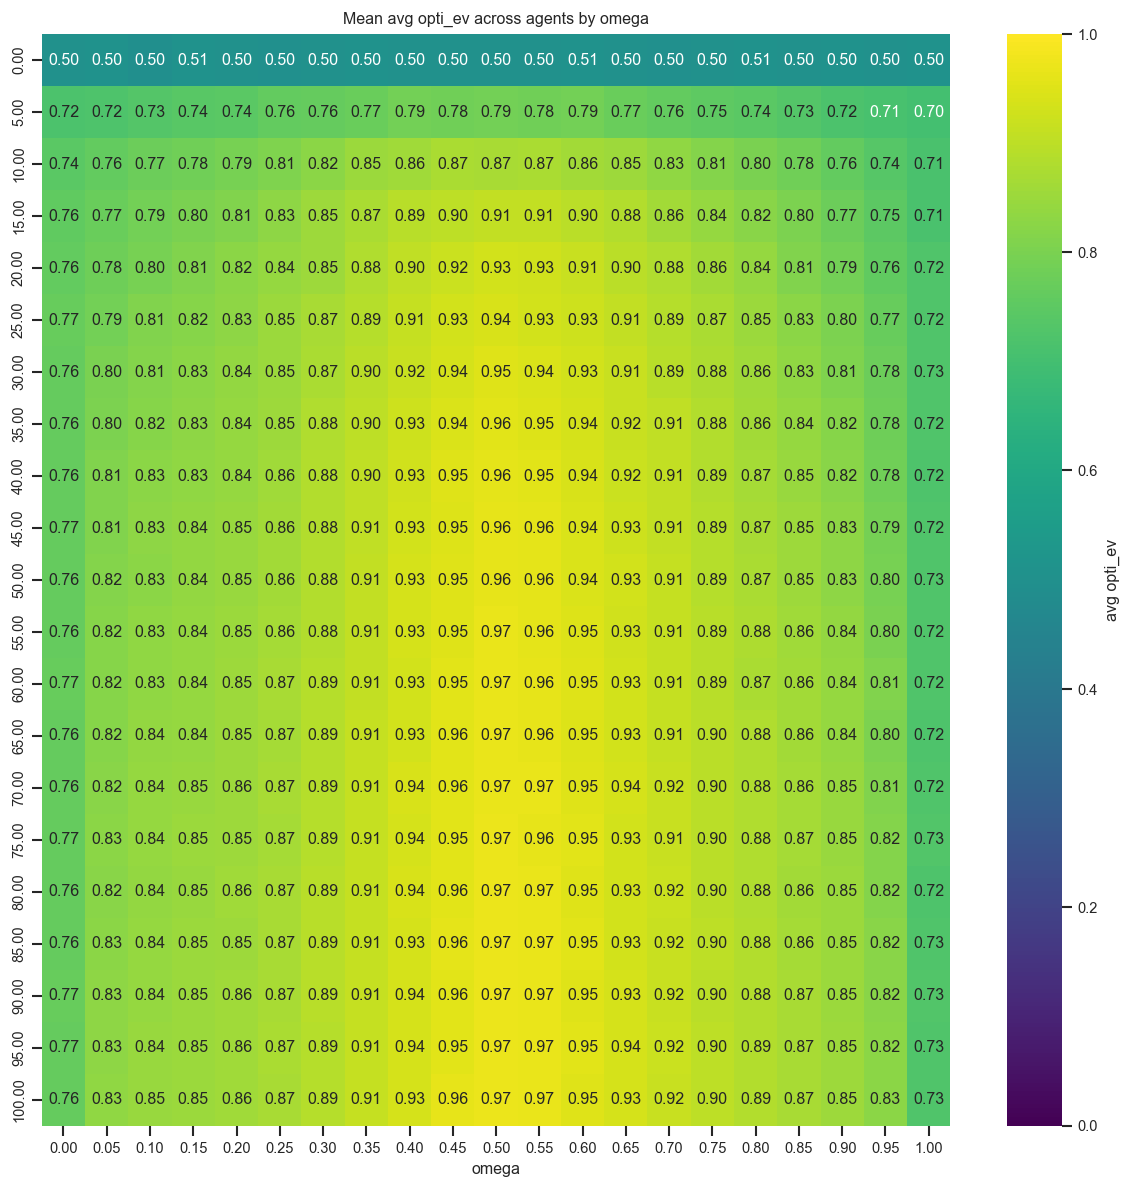

In [41]:
# Mean across agents
mean_per_omega = df_omega_sim.groupby(['omega', 'beta'])['avg_opti_ev'].mean()



plt.figure(figsize=(10, 10))
sns.set_context('notebook', font_scale=0.8)
sns.heatmap(
    mean_per_omega.values.reshape(len(omegas), len(betas)).T,
    annot=True, fmt='.2f',
    cmap='viridis', vmin=0, vmax=1,
    xticklabels=[f'{o:.2f}' for o in omegas],
    yticklabels=[f'{b:.2f}' for b in betas],
    cbar_kws={'label': 'avg opti_ev'},
)
plt.title('Mean avg opti_ev across agents by omega')
plt.xlabel('omega')
plt.tight_layout()
plt.show()


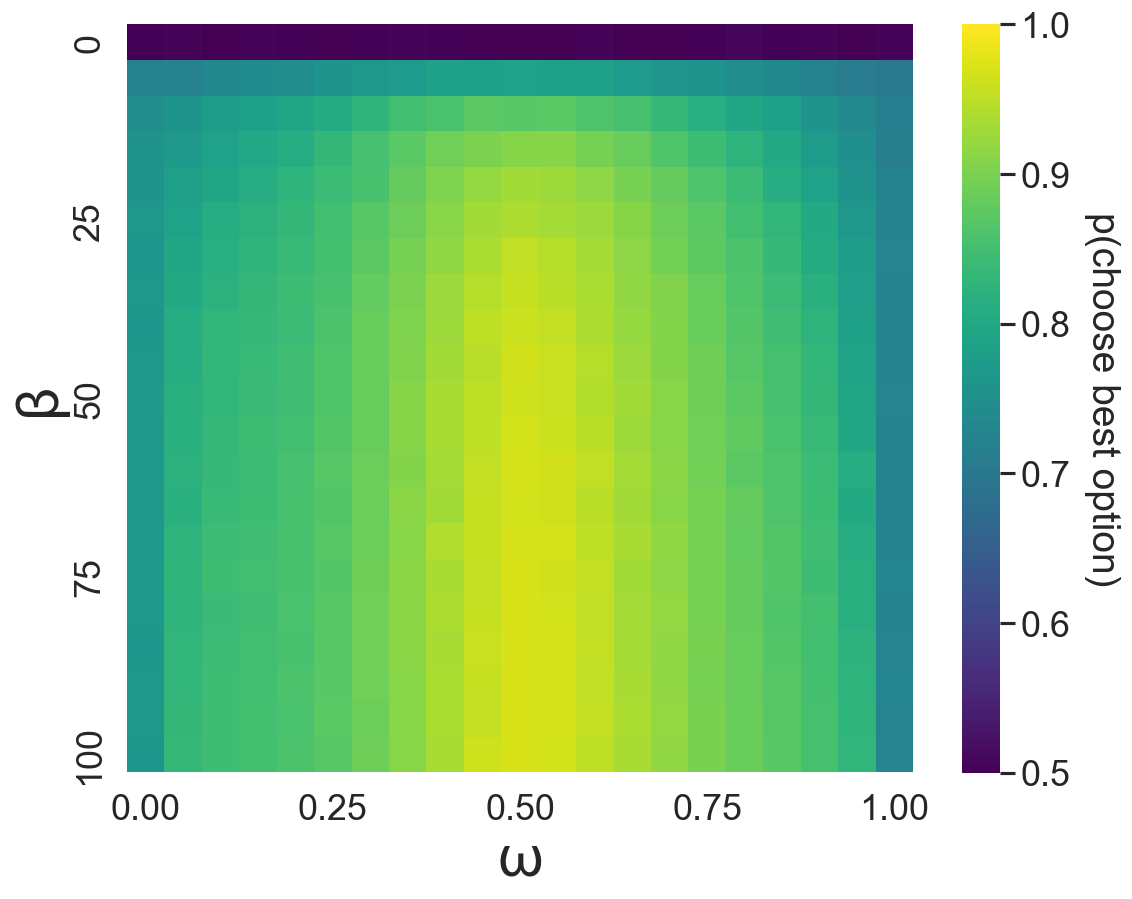

In [42]:
# Mean across agents
mean_per_omega = df_omega_sim.groupby(['omega', 'beta'])['avg_opti_ev'].mean()

sns.set_context('talk', font_scale=1.3)
fig, ax = plt.subplots(figsize=(10, 8))

data_matrix = mean_per_omega.values.reshape(len(omegas), len(betas)).T

sns.heatmap(
    data_matrix,
     fmt='.2f',
    annot_kws={'size': 6},
    cmap='viridis', vmin=.5, vmax=1,
    xticklabels=[f'{o:.2f}' if i % 5 == 0 else '' for i, o in enumerate(omegas)],
    yticklabels=[f'{b:.0f}' if i % 5 == 0 else '' for i, b in enumerate(betas)],
    cbar_kws={'label': 'p(choose best option)'},
    ax=ax,
)
ax.collections[0].colorbar.ax.set_ylabel('p(choose best option)', rotation=270, labelpad=30)

# remove ticks
ax.tick_params(left=False, bottom=False)
ax.set_title('')
ax.set_xlabel('ω', fontsize=35)
ax.set_ylabel('β', fontsize=35)
plt.tight_layout()
plt.show()